In [1]:
import cleaning
import pandas as pd
# Apply the function
df = pd.read_csv('X-cell MF 1 without test .csv')
df_copy = df.copy()  # Create a copy of the original DataFrame
cleaned_df = cleaning.clean_clinical_data(df_copy)
print(cleaned_df.head())

  Age     Sex no. of bx     Diagnosis       Course New, FU, Rec Prev. TTT  \
0  62    male   36\5-25            mf  progressive          new        no   
1  64  female   19\5-25  pl- spectrum  progressive          new       yes   
2  33    male   39\5-25            mf  progressive          rec       yes   
3  25    male   41\5-25            mf  progressive          new        no   
4  65    male   98\5-25            mf  progressive           fu       yes   

      Type of TTT Current TTT Type of current TTT  ... Macules   Patch   \
0             NaN         NaN                 NaN  ...       no     yes   
1  biologics (ps)         NaN                 NaN  ...      yes     yes   
2            puva         NaN                 NaN  ...       no     yes   
3             NaN         NaN                 NaN  ...      yes     yes   
4    puva and mtx         yes        puva and mtx  ...       no     yes   

  Papules  Plaque nodule others scales others.1        Type of MF  \
0       no    yes

In [2]:
cleaned_df.shape

(499, 33)

In [3]:
cleaned_df.isna().sum()

Age                     11
Sex                      0
no. of bx                0
Diagnosis                0
Course                   4
New, FU, Rec             0
Prev. TTT                0
Type of TTT            308
Current TTT            371
Type of current TTT    371
Symptomatic              0
Symptoms               206
Head and Neck            0
UL                       0
LL                       0
Trunk                    0
Buttocks                 0
of BX 1                  7
of BX 2                204
of BX 1.1               54
of  BX 2               300
Stage of MF            146
color                    1
Macules                  0
 Patch                   0
Papules                  0
Plaque                   0
nodule                   0
others                   0
scales                   0
others.1                 0
Type of MF             145
Duration_Months         40
dtype: int64

In [4]:
cleaned_df.describe()

,Duration_Months
count,459.000000
mean,50.655773
std,65.455569
min,1.000000
25%,7.000000
50%,24.000000
75%,60.000000
max,420.000000


In [5]:
structured_df = cleaning.structured_clinical_cleanup(cleaned_df)
structured_df.head()

,Age,Sex,Diagnosis,Course,"New, FU, Rec",Prev. TTT,Type of TTT,Current TTT,Type of current TTT,Symptomatic,...,Macules,Patch,Papules,Plaque,nodule,others,scales,others.1,Type of MF,Duration_Months
0,62.0,male,mf,progressive,new,no,none,none,none,yes,...,no,yes,no,yes,no,no,yes,no,classic mf,120.0
1,64.0,female,pl- spectrum,progressive,new,yes,biologics (ps),none,none,yes,...,yes,yes,yes,no,no,no,yes,no,NaN,1.0
2,33.0,male,mf,progressive,rec,yes,puva,none,none,no,...,no,yes,no,no,no,no,yes,no,classic mf,24.0
3,25.0,male,mf,progressive,new,no,none,none,none,no,...,yes,yes,no,no,no,no,no,no,hypopigmented mf,36.0
4,65.0,male,mf,progressive,fu,yes,puva and mtx,yes,puva and mtx,yes,...,no,yes,no,yes,no,no,yes,no,erythrodermic mf,84.0


In [6]:
structured_df.describe()

,Age,Duration_Months
count,499.000000,459.000000
mean,37.723447,50.655773
std,19.294371,65.455569
min,3.000000,1.000000
25%,22.500000,7.000000
50%,37.000000,24.000000
75%,54.000000,60.000000
max,80.000000,420.000000


In [7]:
# 1. Create the Gatekeeper Target (Is_MF)
# Standardize the text first to catch any ' mf ' or 'Mf' variations
structured_df['Diagnosis_clean'] = structured_df['Diagnosis'].astype(str).str.strip().str.upper()
structured_df['Is_MF'] = structured_df['Diagnosis_clean'].apply(lambda x: 1 if x == 'MF' else 0)

# Drop the temporary cleaning column
structured_df = structured_df.drop(columns=['Diagnosis_clean'])

# 2. Prepare Gatekeeper Dataset (Task: Predict Is_MF)
# CRITICAL: We must drop Diagnosis, Stage, and Type columns here.
# If we don't, the model will cheat (Data Leakage).
gatekeeper_leakage_cols = ['Diagnosis', 'Stage of MF', 'Type of MF','Prev. TTT', 'Type of TTT', 'Current TTT', 'Type of current TTT' ]
df_gatekeeper = structured_df.drop(columns=[col for col in gatekeeper_leakage_cols if col in structured_df.columns])

# 3. Prepare Specialist Dataset (Task: Predict Stage of MF)
# Filter ONLY the patients who actually have MF (Is_MF == 1)
df_specialist = structured_df[structured_df['Is_MF'] == 1].copy()

# Drop the 'Is_MF' column here since it's 1 for every single row and provides no variance
# We also drop 'Diagnosis' since it is redundant now. 
# We keep 'Stage of MF' as our target (y) for this dataset.
df_specialist = df_specialist.drop(columns=['Is_MF', 'Diagnosis'])

# 4. Verify the splits
print("--- Dataset Shapes ---")
print(f"Original Cleaned Data: {structured_df.shape}")
print(f"Gatekeeper Data (For Binary Classification): {df_gatekeeper.shape}")
print(f"Specialist Data (For Multi-class Classification): {df_specialist.shape}")

--- Dataset Shapes ---
Original Cleaned Data: (499, 33)
Gatekeeper Data (For Binary Classification): (499, 26)
Specialist Data (For Multi-class Classification): (353, 31)


In [8]:
# --- For Model 1: The Gatekeeper ---
X_gatekeeper = df_gatekeeper.drop(columns=['Is_MF'])
y_gatekeeper = df_gatekeeper['Is_MF']

# --- For Model 2: The Specialist ---
# Assuming 'Stage of MF' is your exact column name for the target
# Drop any rows where Stage of MF might STILL be missing despite our filtering
df_specialist = df_specialist.dropna(subset=['Stage of MF'])

X_specialist = df_specialist.drop(columns=['Stage of MF', 'Type of MF']) # Drop 'Type' so it doesn't leak into 'Stage'
y_specialist = df_specialist['Stage of MF']

print("\n--- Target Distributions ---")
print("Gatekeeper Target Distribution (Is_MF):")
print(y_gatekeeper.value_counts())

print("\nSpecialist Target Distribution (Stage of MF):")
print(y_specialist.value_counts())


--- Target Distributions ---
Gatekeeper Target Distribution (Is_MF):
Is_MF
1    353
0    146
Name: count, dtype: int64

Specialist Target Distribution (Stage of MF):
Stage of MF
patch-plaque    326
tumor            27
Name: count, dtype: int64


In [9]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 1) Build target and feature table
structured_df['Diagnosis_clean'] = structured_df['Diagnosis'].astype(str).str.strip().str.upper()
structured_df['Is_MF'] = (structured_df['Diagnosis_clean'] == 'MF').astype(int)
structured_df = structured_df.drop(columns=['Diagnosis_clean'])

# Drop leakage columns (including treatment-history leakage)
leakage_cols = [
    'Diagnosis', 'Stage of MF', 'Type of MF',
    'Prev. TTT', 'Type of TTT', 'Current TTT', 'Type of current TTT'
 ]
df_gatekeeper = structured_df.drop(columns=[c for c in leakage_cols if c in structured_df.columns])

X = df_gatekeeper.drop(columns=['Is_MF'])
y = df_gatekeeper['Is_MF']

# 2) Split BEFORE preprocessing (prevents leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) Column groups
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

# 4) Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 5) Imbalance weight for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight_value = neg / pos if pos > 0 else 1.0

# 6) Models
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Support Vector Machine": SVC(class_weight='balanced', probability=True, random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight_value, eval_metric='logloss', random_state=42)
}

# 7) Train and evaluate
print("--- Gatekeeper Model Benchmark Results ---\n")

fitted_pipelines = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    fitted_pipelines[name] = clf

    print(f"=== {name} ===")
    print(f"ROC-AUC Score: {auc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 40 + "\n")

--- Gatekeeper Model Benchmark Results ---

=== Logistic Regression ===
ROC-AUC Score: 0.9956
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        29
           1       0.99      0.96      0.97        71

    accuracy                           0.96       100
   macro avg       0.94      0.96      0.95       100
weighted avg       0.96      0.96      0.96       100

----------------------------------------

=== Random Forest ===
ROC-AUC Score: 0.9954
              precision    recall  f1-score   support

           0       0.93      0.90      0.91        29
           1       0.96      0.97      0.97        71

    accuracy                           0.95       100
   macro avg       0.94      0.93      0.94       100
weighted avg       0.95      0.95      0.95       100

----------------------------------------

=== Support Vector Machine ===
ROC-AUC Score: 0.8946
              precision    recall  f1-score   support

           0    

In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score
from sklearn.utils.multiclass import type_of_target
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 1) Build Specialist dataset from MF-only rows
df_specialist = structured_df[structured_df['Is_MF'] == 1].copy()
df_specialist = df_specialist.dropna(subset=['Stage of MF'])

# Drop leakage/redundant columns for Specialist task (including treatment-history leakage)
specialist_drop_cols = [
    'Stage of MF', 'Type of MF', 'Diagnosis', 'Is_MF',
    'Prev. TTT', 'Type of TTT', 'Current TTT', 'Type of current TTT'
 ]
X_specialist = df_specialist.drop(columns=[c for c in specialist_drop_cols if c in df_specialist.columns])

# Normalize target text and encode labels
y_specialist_raw = df_specialist['Stage of MF'].astype(str).str.strip().str.lower()
label_encoder = LabelEncoder()
y_specialist = label_encoder.fit_transform(y_specialist_raw)

# Basic safety checks
n_classes = len(np.unique(y_specialist))
if n_classes < 2:
    raise ValueError("Specialist target has fewer than 2 classes after filtering. Cannot train multiclass model.")

# If a class has only 1 sample, stratified split will fail. Fallback to non-stratified split.
min_class_count = pd.Series(y_specialist).value_counts().min()
stratify_target = y_specialist if min_class_count >= 2 else None

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_specialist,
    y_specialist,
    test_size=0.2,
    random_state=42,
    stratify=stratify_target
)

# 2) Preprocessing
numeric_features = X_train_s.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train_s.select_dtypes(exclude=['number']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_s = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 3) Specialist model candidates (multiclass)
models_s = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    "Support Vector Machine": SVC(
        class_weight='balanced',
        probability=True,
        random_state=42
    ),
    "XGBoost (Multiclass)": XGBClassifier(
        objective='multi:softprob',
        num_class=n_classes,
        eval_metric='mlogloss',
        random_state=42
    )
}
# 4) Train + evaluate
specialist_results = {}

print("--- Specialist Model Benchmark Results (Stage of MF) ---\n")
print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} -> {cls}")
print("")

for name, model in models_s.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor_s),
        ('model', model)
    ])

    clf.fit(X_train_s, y_train_s)
    y_pred_s = clf.predict(X_test_s)

    # Normalize target format for metrics
    y_true_eval = np.asarray(y_test_s)
    y_pred_eval = np.asarray(y_pred_s)

    if y_true_eval.ndim > 1:
        y_true_eval = np.argmax(y_true_eval, axis=1)

    if y_pred_eval.ndim > 1:
        # If indicator/probability-like output, convert to class index
        y_pred_eval = np.argmax(y_pred_eval, axis=1)

    y_true_eval = y_true_eval.astype(int).ravel()
    y_pred_eval = y_pred_eval.astype(int).ravel()

    bal_acc = balanced_accuracy_score(y_true_eval, y_pred_eval)
    macro_f1 = f1_score(y_true_eval, y_pred_eval, average='macro')

    specialist_results[name] = {
        'pipeline': clf,
        'balanced_accuracy': bal_acc,
        'macro_f1': macro_f1
    }

    print(f"=== {name} ===")
    print("y_true type:", type_of_target(y_true_eval), "| y_pred type:", type_of_target(y_pred_eval))
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(classification_report(
        y_true_eval,
        y_pred_eval,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    ))
    print("-" * 50 + "\n")

--- Specialist Model Benchmark Results (Stage of MF) ---

Class mapping:
  0 -> patch-plaque
  1 -> tumor

=== Logistic Regression ===
y_true type: binary | y_pred type: binary
Balanced Accuracy: 0.7621
Macro F1: 0.7036
              precision    recall  f1-score   support

patch-plaque       0.97      0.92      0.95        66
       tumor       0.38      0.60      0.46         5

    accuracy                           0.90        71
   macro avg       0.67      0.76      0.70        71
weighted avg       0.93      0.90      0.91        71

--------------------------------------------------

=== Random Forest ===
y_true type: binary | y_pred type: binary
Balanced Accuracy: 0.7924
Macro F1: 0.8221
              precision    recall  f1-score   support

patch-plaque       0.97      0.98      0.98        66
       tumor       0.75      0.60      0.67         5

    accuracy                           0.96        71
   macro avg       0.86      0.79      0.82        71
weighted avg       0.9

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, f1_score, balanced_accuracy_score, classification_report

# Helper: force predictions/targets to 1D class indices
def to_1d_labels(arr):
    arr = np.asarray(arr)
    if arr.ndim > 1:
        arr = np.argmax(arr, axis=1)
    return arr.astype(int).ravel()

# Ground truth from your existing split
y_true_eval = to_1d_labels(y_test_s)

# Evaluate each trained specialist model
leaderboard_rows = []
specialist_predictions = {}

for model_name, pack in specialist_results.items():
    clf = pack['pipeline']
    y_pred_eval = to_1d_labels(clf.predict(X_test_s))

    # Recall-focused metrics
    recall_macro = recall_score(y_true_eval, y_pred_eval, average='macro', zero_division=0)
    recall_weighted = recall_score(y_true_eval, y_pred_eval, average='weighted', zero_division=0)
    recall_per_class = recall_score(
        y_true_eval,
        y_pred_eval,
        labels=np.arange(len(label_encoder.classes_)),
        average=None,
        zero_division=0
    )
    min_class_recall = float(np.min(recall_per_class))  # protects worst-detected class

    # Secondary metrics
    macro_f1 = f1_score(y_true_eval, y_pred_eval, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_true_eval, y_pred_eval)

    # Recall-first clinical score (tunable)
    clinical_score = 0.60 * recall_macro + 0.30 * min_class_recall + 0.10 * macro_f1

    leaderboard_rows.append({
        'Model': model_name,
        'Recall_macro': recall_macro,
        'Recall_weighted': recall_weighted,
        'Min_class_recall': min_class_recall,
        'Macro_F1': macro_f1,
        'Balanced_Accuracy': bal_acc,
        'Clinical_score': clinical_score
    })

    specialist_predictions[model_name] = y_pred_eval

# Build and sort leaderboard (recall-first)
leaderboard = pd.DataFrame(leaderboard_rows).sort_values(
    by=['Clinical_score', 'Recall_macro', 'Min_class_recall', 'Macro_F1'],
    ascending=False
).reset_index(drop=True)

print("--- Specialist Leaderboard (Recall-First) ---")
print(leaderboard)

# Pick final specialist model
final_specialist_model_name = leaderboard.loc[0, 'Model']
final_specialist_model = specialist_results[final_specialist_model_name]['pipeline']
final_specialist_pred = specialist_predictions[final_specialist_model_name]

print("\nSelected final specialist model:", final_specialist_model_name)

# Detailed report for selected model
print("\n--- Final Specialist Classification Report ---")
print(classification_report(
    y_true_eval,
    final_specialist_pred,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))

# Per-class recall table (important medically)
report_dict = classification_report(
    y_true_eval,
    final_specialist_pred,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

recall_table = pd.DataFrame({
    'Stage': label_encoder.classes_,
    'Recall': [report_dict[stage]['recall'] for stage in label_encoder.classes_]
}).sort_values(by='Recall')

print("\n--- Per-Class Recall (Lowest First) ---")
print(recall_table)

--- Specialist Leaderboard (Recall-First) ---
                    Model  Recall_macro  Recall_weighted  Min_class_recall  \
0    XGBoost (Multiclass)      0.877273         0.943662          0.800000   
1           Random Forest      0.792424         0.957746          0.600000   
2     Logistic Regression      0.762121         0.901408          0.600000   
3  Support Vector Machine      0.366667         0.338028          0.333333   

   Macro_F1  Balanced_Accuracy  Clinical_score  
0  0.817949           0.877273        0.848159  
1  0.822055           0.792424        0.737660  
2  0.703637           0.762121        0.707636  
3  0.280974           0.366667        0.348097  

Selected final specialist model: XGBoost (Multiclass)

--- Final Specialist Classification Report ---
              precision    recall  f1-score   support

patch-plaque       0.98      0.95      0.97        66
       tumor       0.57      0.80      0.67         5

    accuracy                           0.94        

Best Gatekeeper (recall-first): XGBoost

Gatekeeper summary:
                    Model  Sensitivity_Recall_MF  Specificity_nonMF   ROC_AUC  \
0                 XGBoost               0.985915           0.965517  0.998543   
1           Random Forest               0.971831           0.896552  0.995386   
2     Logistic Regression               0.957746           0.965517  0.995629   
3  Support Vector Machine               0.845070           0.724138  0.894609   

   PR_AUC_AP  
0   0.999429  
1   0.998051  
2   0.998273  
3   0.952348  


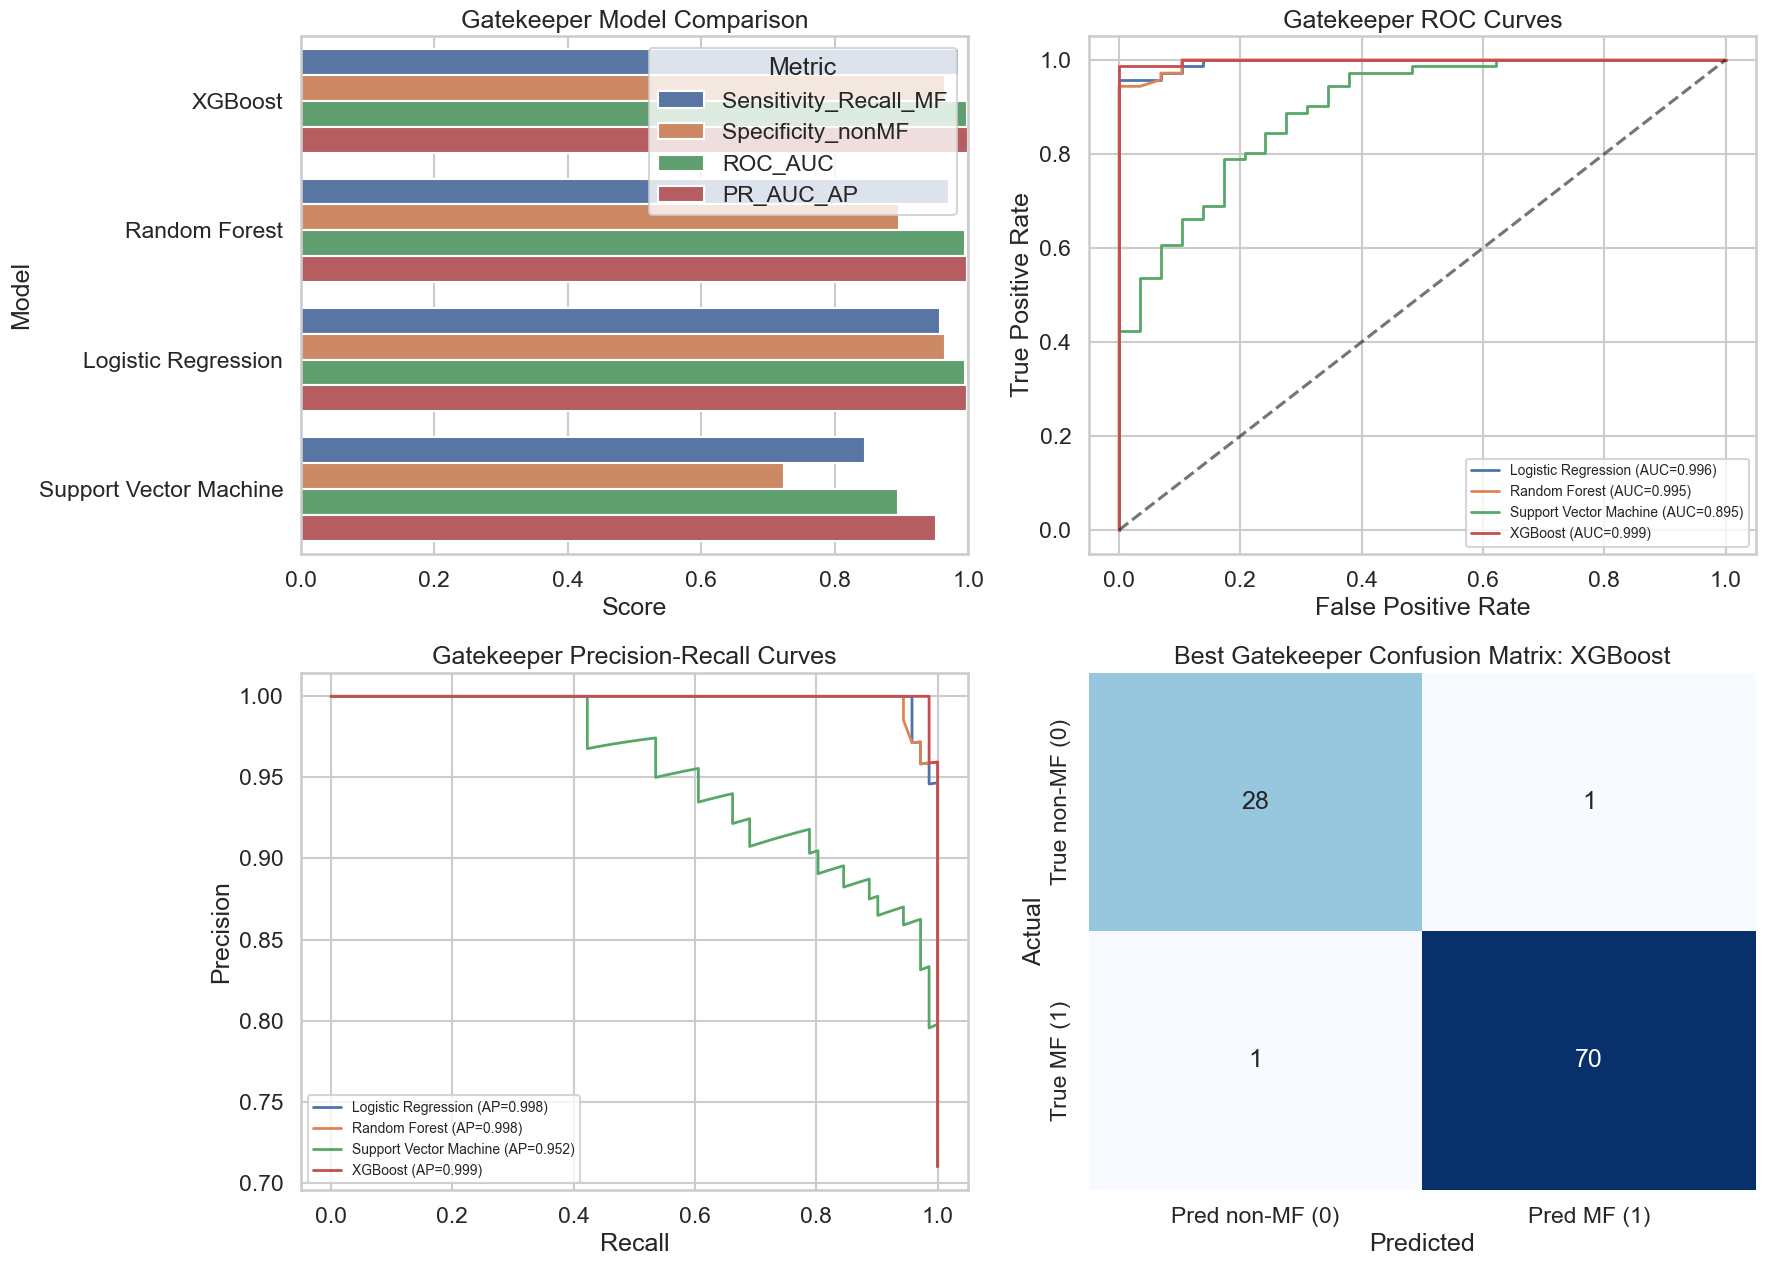


Best Gatekeeper classification report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.99      0.99      0.99        71

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [12]:
# =========================
# FIGURES: GATEKEEPER MODEL
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid", context="talk")

# Safety checks
if "fitted_pipelines" not in globals():
    raise ValueError("Run gatekeeper training cell first (fitted_pipelines not found).")
if "X_test" not in globals() or "y_test" not in globals():
    raise ValueError("X_test/y_test not found. Run gatekeeper split/training first.")

def get_binary_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s = np.asarray(s).ravel()
        # Min-max normalize to 0..1 for plotting curves
        s_min, s_max = s.min(), s.max()
        if s_max > s_min:
            return (s - s_min) / (s_max - s_min)
        return np.zeros_like(s, dtype=float)
    # Fallback if neither method exists
    return model.predict(X).astype(float)

gate_rows = []
roc_curves = {}
pr_curves = {}
pred_cache = {}

for model_name, clf in fitted_pipelines.items():
    y_pred = clf.predict(X_test)
    y_score = get_binary_scores(clf, X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall for MF
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall for non-MF

    fpr, tpr, _ = roc_curve(y_test, y_score)
    precision, recall, _ = precision_recall_curve(y_test, y_score)

    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_test, y_score)

    gate_rows.append({
        "Model": model_name,
        "Sensitivity_Recall_MF": sensitivity,
        "Specificity_nonMF": specificity,
        "ROC_AUC": roc_auc,
        "PR_AUC_AP": ap
    })

    roc_curves[model_name] = (fpr, tpr, roc_auc)
    pr_curves[model_name] = (recall, precision, ap)
    pred_cache[model_name] = y_pred

gate_df = pd.DataFrame(gate_rows).sort_values(
    by=["Sensitivity_Recall_MF", "PR_AUC_AP", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

best_gatekeeper_name = gate_df.loc[0, "Model"]
best_gatekeeper_pred = pred_cache[best_gatekeeper_name]

print("Best Gatekeeper (recall-first):", best_gatekeeper_name)
print("\nGatekeeper summary:")
print(gate_df)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# 1) Recall-focused bar chart
plot_cols = ["Sensitivity_Recall_MF", "Specificity_nonMF", "ROC_AUC", "PR_AUC_AP"]
gate_plot = gate_df.melt(id_vars="Model", value_vars=plot_cols, var_name="Metric", value_name="Value")
sns.barplot(data=gate_plot, x="Value", y="Model", hue="Metric", ax=axes[0, 0])
axes[0, 0].set_title("Gatekeeper Model Comparison")
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_xlabel("Score")
axes[0, 0].set_ylabel("Model")

# 2) ROC curves
for name, (fpr, tpr, roc_auc) in roc_curves.items():
    axes[0, 1].plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.6)
axes[0, 1].set_title("Gatekeeper ROC Curves")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend(loc="lower right", fontsize=10)

# 3) Precision-Recall curves (important for imbalance)
for name, (recall, precision, ap) in pr_curves.items():
    axes[1, 0].plot(recall, precision, lw=2, label=f"{name} (AP={ap:.3f})")
axes[1, 0].set_title("Gatekeeper Precision-Recall Curves")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend(loc="lower left", fontsize=10)

# 4) Confusion matrix of best gatekeeper
cm_gate = confusion_matrix(y_test, best_gatekeeper_pred, labels=[0, 1])
sns.heatmap(
    cm_gate, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1, 1],
    xticklabels=["Pred non-MF (0)", "Pred MF (1)"],
    yticklabels=["True non-MF (0)", "True MF (1)"]
)
axes[1, 1].set_title(f"Best Gatekeeper Confusion Matrix: {best_gatekeeper_name}")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("\nBest Gatekeeper classification report:")
print(classification_report(y_test, best_gatekeeper_pred, zero_division=0))

Best Specialist (recall-first): XGBoost (Multiclass)

Specialist summary:
                    Model  Recall_macro  Recall_weighted  Min_class_recall  \
0    XGBoost (Multiclass)      0.877273         0.943662          0.800000   
1           Random Forest      0.792424         0.957746          0.600000   
2     Logistic Regression      0.762121         0.901408          0.600000   
3  Support Vector Machine      0.366667         0.338028          0.333333   

   Macro_F1  Balanced_Accuracy  Clinical_score  
0  0.817949           0.877273        0.848159  
1  0.822055           0.792424        0.737660  
2  0.703637           0.762121        0.707636  
3  0.280974           0.366667        0.348097  


C:\Users\TiTo0\AppData\Local\Temp\ipykernel_3308\399305654.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=spec_df, x="Clinical_score", y="Model", palette="viridis", ax=axes[0, 0])


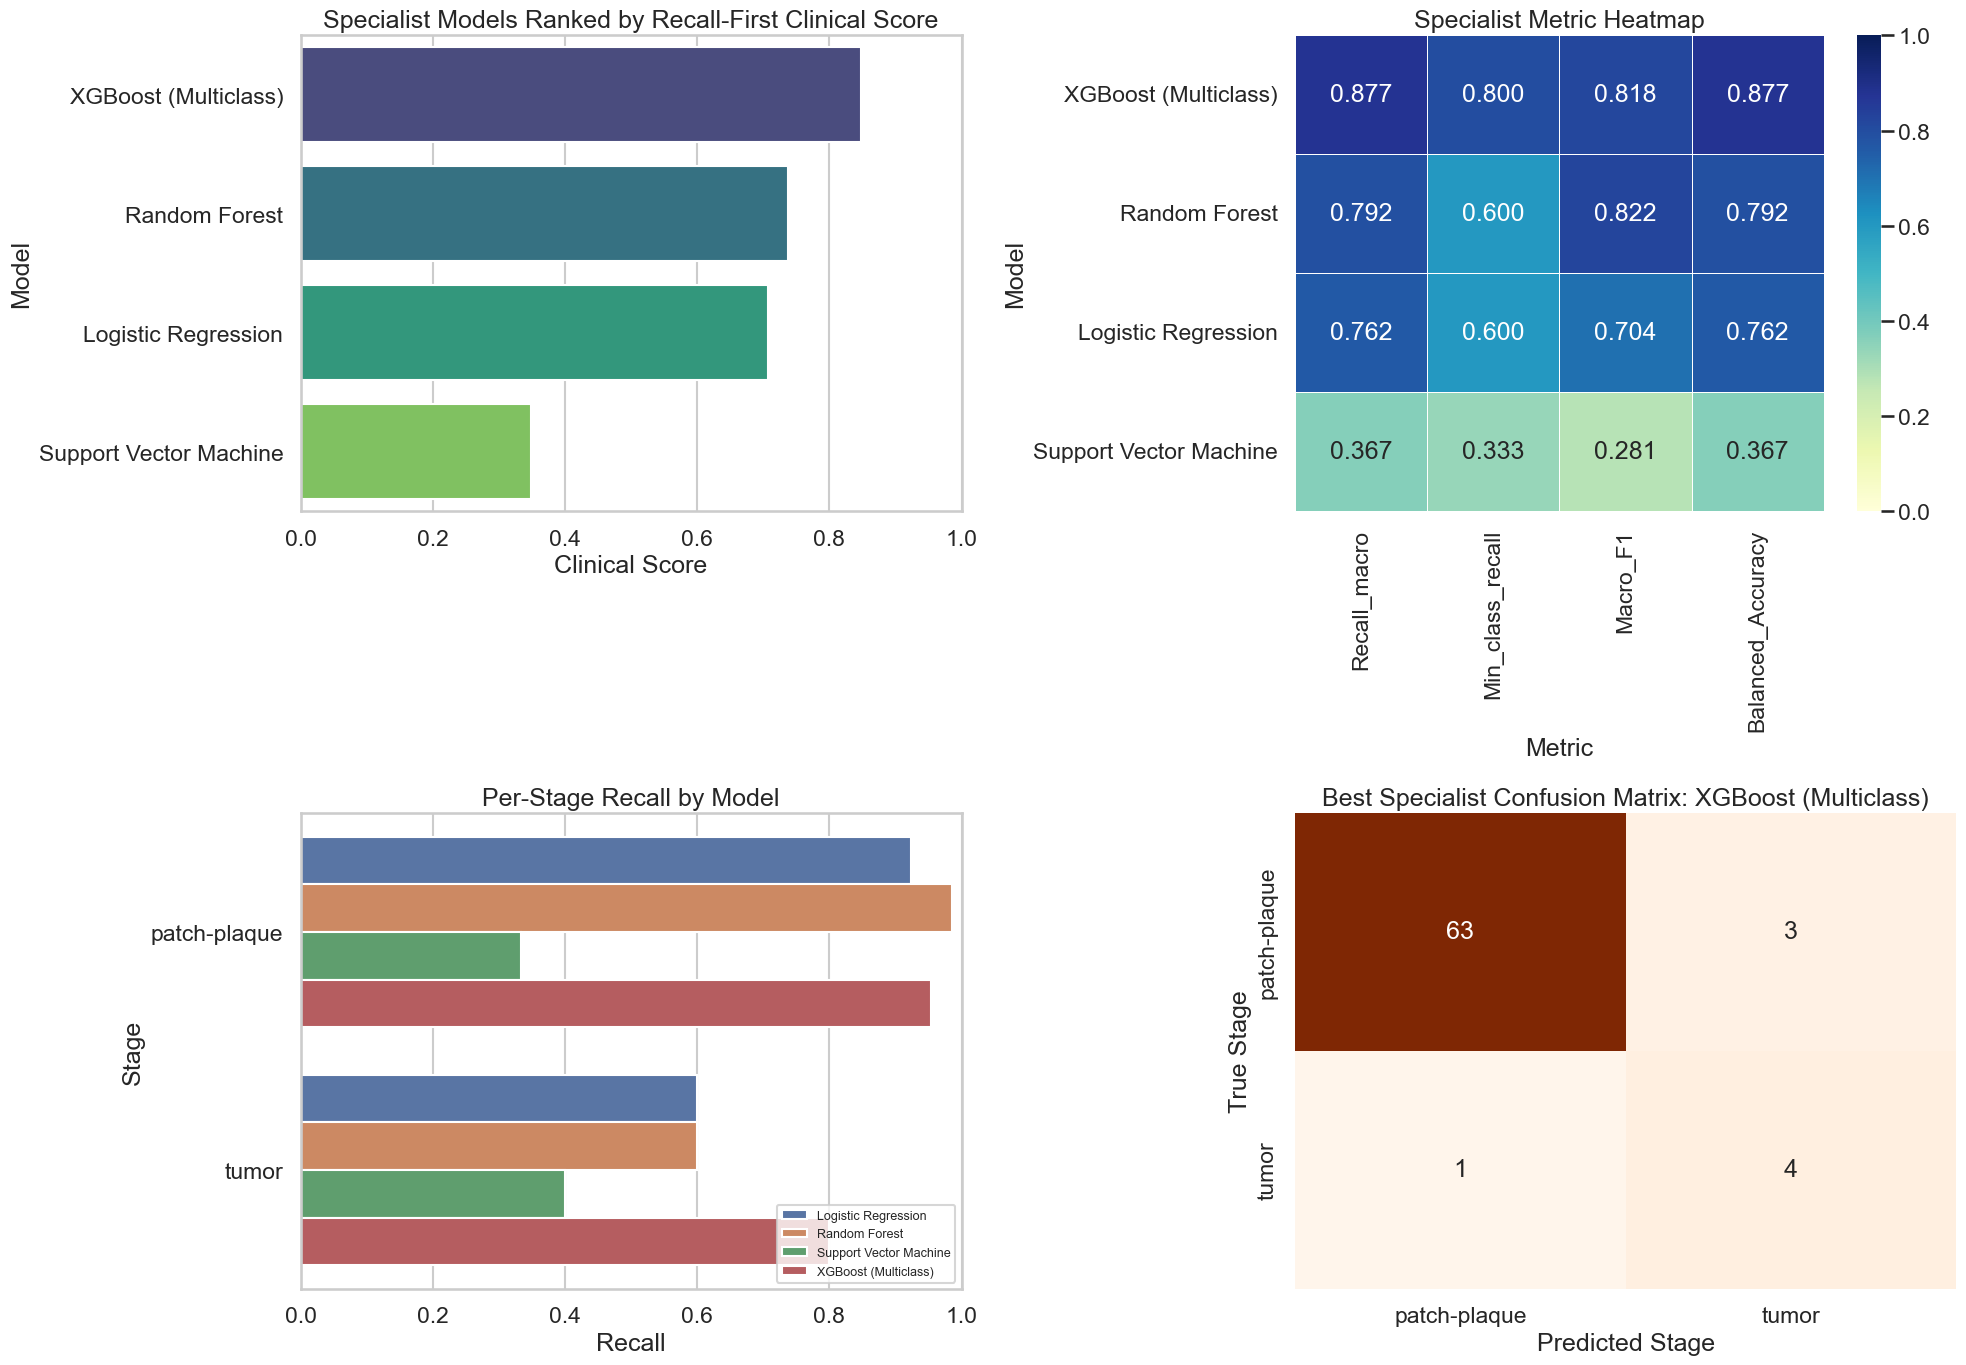


Best Specialist classification report:
              precision    recall  f1-score   support

patch-plaque       0.98      0.95      0.97        66
       tumor       0.57      0.80      0.67         5

    accuracy                           0.94        71
   macro avg       0.78      0.88      0.82        71
weighted avg       0.96      0.94      0.95        71



In [13]:
# =========================
# FIGURES: SPECIALIST MODEL
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    recall_score, f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid", context="talk")

# Safety checks
if "specialist_results" not in globals():
    raise ValueError("Run specialist training cell first (specialist_results not found).")
if "X_test_s" not in globals() or "y_test_s" not in globals():
    raise ValueError("X_test_s/y_test_s not found. Run specialist split/training first.")
if "label_encoder" not in globals():
    raise ValueError("label_encoder not found. Run specialist encoding/training first.")

def to_1d_labels(arr):
    arr = np.asarray(arr)
    if arr.ndim > 1:
        arr = np.argmax(arr, axis=1)
    return arr.astype(int).ravel()

y_true_s = to_1d_labels(y_test_s)
classes = np.arange(len(label_encoder.classes_))
class_names = label_encoder.classes_

spec_rows = []
spec_pred_cache = {}
per_class_recall_rows = []

for model_name, pack in specialist_results.items():
    clf = pack["pipeline"]
    y_pred_s = to_1d_labels(clf.predict(X_test_s))

    recall_macro = recall_score(y_true_s, y_pred_s, average="macro", zero_division=0)
    recall_weighted = recall_score(y_true_s, y_pred_s, average="weighted", zero_division=0)
    recall_per_class = recall_score(y_true_s, y_pred_s, labels=classes, average=None, zero_division=0)
    min_class_recall = float(np.min(recall_per_class))
    macro_f1 = f1_score(y_true_s, y_pred_s, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true_s, y_pred_s)

    clinical_score = 0.60 * recall_macro + 0.30 * min_class_recall + 0.10 * macro_f1

    spec_rows.append({
        "Model": model_name,
        "Recall_macro": recall_macro,
        "Recall_weighted": recall_weighted,
        "Min_class_recall": min_class_recall,
        "Macro_F1": macro_f1,
        "Balanced_Accuracy": bal_acc,
        "Clinical_score": clinical_score
    })

    for idx, stage_name in enumerate(class_names):
        per_class_recall_rows.append({
            "Model": model_name,
            "Stage": stage_name,
            "Recall": recall_per_class[idx]
        })

    spec_pred_cache[model_name] = y_pred_s

spec_df = pd.DataFrame(spec_rows).sort_values(
    by=["Clinical_score", "Recall_macro", "Min_class_recall"],
    ascending=False
).reset_index(drop=True)

best_specialist_name = spec_df.loc[0, "Model"]
best_specialist_pred = spec_pred_cache[best_specialist_name]

print("Best Specialist (recall-first):", best_specialist_name)
print("\nSpecialist summary:")
print(spec_df)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# 1) Clinical score ranking
sns.barplot(data=spec_df, x="Clinical_score", y="Model", palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Specialist Models Ranked by Recall-First Clinical Score")
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_xlabel("Clinical Score")
axes[0, 0].set_ylabel("Model")

# 2) Heatmap of key metrics
metric_cols = ["Recall_macro", "Min_class_recall", "Macro_F1", "Balanced_Accuracy"]
heat_df = spec_df.set_index("Model")[metric_cols]
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5, ax=axes[0, 1])
axes[0, 1].set_title("Specialist Metric Heatmap")
axes[0, 1].set_xlabel("Metric")
axes[0, 1].set_ylabel("Model")

# 3) Per-class recall by model
per_class_df = pd.DataFrame(per_class_recall_rows)
sns.barplot(data=per_class_df, x="Recall", y="Stage", hue="Model", ax=axes[1, 0])
axes[1, 0].set_title("Per-Stage Recall by Model")
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Stage")
axes[1, 0].legend(loc="lower right", fontsize=9)

# 4) Confusion matrix for best specialist model
cm_spec = confusion_matrix(y_true_s, best_specialist_pred, labels=classes)
sns.heatmap(
    cm_spec, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[1, 1],
    xticklabels=class_names, yticklabels=class_names
)
axes[1, 1].set_title(f"Best Specialist Confusion Matrix: {best_specialist_name}")
axes[1, 1].set_xlabel("Predicted Stage")
axes[1, 1].set_ylabel("True Stage")

plt.tight_layout()
plt.show()

print("\nBest Specialist classification report:")
print(classification_report(
    y_true_s, best_specialist_pred,
    labels=classes, target_names=class_names, zero_division=0
))

In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score, f1_score, recall_score
)
from sklearn.utils.class_weight import compute_sample_weight

# -----------------------------
# Shared leakage policy
# -----------------------------
treatment_leakage_cols = ['Prev. TTT', 'Type of TTT', 'Current TTT', 'Type of current TTT']

# ==========================================
# A) GATEKEEPER NN (Binary: Is_MF)
# ==========================================
gatekeeper_drop_cols = ['Diagnosis', 'Stage of MF', 'Type of MF'] + treatment_leakage_cols
df_gatekeeper_nn = structured_df.drop(columns=[c for c in gatekeeper_drop_cols if c in structured_df.columns])

X_g = df_gatekeeper_nn.drop(columns=['Is_MF'])
y_g = df_gatekeeper_nn['Is_MF'].astype(int)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_g, y_g, test_size=0.2, random_state=42, stratify=y_g
)

num_cols_g = Xg_train.select_dtypes(include=['number']).columns.tolist()
cat_cols_g = Xg_train.select_dtypes(exclude=['number']).columns.tolist()

pre_g = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols_g),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_g)
    ]
)

Xg_train_enc = pre_g.fit_transform(Xg_train)
Xg_test_enc = pre_g.transform(Xg_test)

nn_gatekeeper = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

# Try weighted training if supported by your sklearn build
sw_g = compute_sample_weight(class_weight='balanced', y=yg_train)
try:
    nn_gatekeeper.fit(Xg_train_enc, yg_train, sample_weight=sw_g)
    print("Gatekeeper NN trained with sample weights.")
except TypeError:
    nn_gatekeeper.fit(Xg_train_enc, yg_train)
    print("Gatekeeper NN trained without sample weights (this sklearn build does not support sample_weight for MLP).")

# Recall-first threshold tuning
yg_prob = nn_gatekeeper.predict_proba(Xg_test_enc)[:, 1]
thresholds = np.linspace(0.10, 0.90, 81)

best_t, best_recall, best_spec = 0.5, -1, -1
for t in thresholds:
    yg_pred_t = (yg_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yg_test, yg_pred_t, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    # Recall-first with mild specificity guard
    if spec >= 0.70 and rec > best_recall:
        best_recall, best_spec, best_t = rec, spec, t

yg_pred = (yg_prob >= best_t).astype(int)

print("\n=== Gatekeeper NN Results ===")
print("Chosen threshold:", round(best_t, 3))
print("ROC-AUC:", round(roc_auc_score(yg_test, yg_prob), 4))
print(classification_report(yg_test, yg_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(yg_test, yg_pred, labels=[0, 1]))

# ==========================================
# B) SPECIALIST NN (Multiclass: Stage of MF)
# ==========================================
df_spec_nn = structured_df[structured_df['Is_MF'] == 1].copy()
df_spec_nn = df_spec_nn.dropna(subset=['Stage of MF'])

specialist_drop_cols_nn = ['Stage of MF', 'Type of MF', 'Diagnosis', 'Is_MF'] + treatment_leakage_cols
X_s = df_spec_nn.drop(columns=[c for c in specialist_drop_cols_nn if c in df_spec_nn.columns])

y_s_raw = df_spec_nn['Stage of MF'].astype(str).str.strip().str.lower()
le_stage = LabelEncoder()
y_s = le_stage.fit_transform(y_s_raw)

min_count = pd.Series(y_s).value_counts().min()
stratify_s = y_s if min_count >= 2 else None

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42, stratify=stratify_s
)

num_cols_s = Xs_train.select_dtypes(include=['number']).columns.tolist()
cat_cols_s = Xs_train.select_dtypes(exclude=['number']).columns.tolist()

pre_s = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols_s),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_s)
    ]
)

Xs_train_enc = pre_s.fit_transform(Xs_train)
Xs_test_enc = pre_s.transform(Xs_test)

nn_specialist = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=25,
    random_state=42
)

sw_s = compute_sample_weight(class_weight='balanced', y=ys_train)
try:
    nn_specialist.fit(Xs_train_enc, ys_train, sample_weight=sw_s)
    print("\nSpecialist NN trained with sample weights.")
except TypeError:
    nn_specialist.fit(Xs_train_enc, ys_train)
    print("\nSpecialist NN trained without sample weights (this sklearn build does not support sample_weight for MLP).")

ys_pred = nn_specialist.predict(Xs_test_enc)

print("\n=== Specialist NN Results ===")
print("Balanced Accuracy:", round(balanced_accuracy_score(ys_test, ys_pred), 4))
print("Macro F1:", round(f1_score(ys_test, ys_pred, average='macro', zero_division=0), 4))
print("Macro Recall:", round(recall_score(ys_test, ys_pred, average='macro', zero_division=0), 4))
print(classification_report(
    ys_test, ys_pred,
    labels=np.arange(len(le_stage.classes_)),
    target_names=le_stage.classes_,
    zero_division=0
))
print("Confusion matrix:\n", confusion_matrix(ys_test, ys_pred, labels=np.arange(len(le_stage.classes_))))

# Save for later use
nn_artifacts = {
    'gatekeeper_model': nn_gatekeeper,
    'gatekeeper_preprocessor': pre_g,
    'gatekeeper_threshold': best_t,
    'specialist_model': nn_specialist,
    'specialist_preprocessor': pre_s,
    'specialist_label_encoder': le_stage
}

Gatekeeper NN trained with sample weights.

=== Gatekeeper NN Results ===
Chosen threshold: 0.11
ROC-AUC: 0.9976
              precision    recall  f1-score   support

           0       1.00      0.72      0.84        29
           1       0.90      1.00      0.95        71

    accuracy                           0.92       100
   macro avg       0.95      0.86      0.89       100
weighted avg       0.93      0.92      0.92       100

Confusion matrix:
 [[21  8]
 [ 0 71]]

Specialist NN trained with sample weights.

=== Specialist NN Results ===
Balanced Accuracy: 0.747
Macro F1: 0.6646
Macro Recall: 0.747
              precision    recall  f1-score   support

patch-plaque       0.97      0.89      0.93        66
       tumor       0.30      0.60      0.40         5

    accuracy                           0.87        71
   macro avg       0.63      0.75      0.66        71
weighted avg       0.92      0.87      0.89        71

Confusion matrix:
 [[59  7]
 [ 2  3]]


--- Gatekeeper Comparison ---
            Model        Task  Recall_MF  Precision_MF     F1_MF   ROC_AUC  \
0         XGBoost  Gatekeeper   0.985915      0.985915  0.985915  0.998543   
1  Neural Network  Gatekeeper   1.000000      0.898734  0.946667  0.997572   

     PR_AUC  
0  0.999429  
1  0.999010  

--- Specialist Comparison ---
            Model        Task  Recall_macro  Min_class_recall  Macro_F1  \
0         XGBoost  Specialist      0.877273               0.8  0.817949   
1  Neural Network  Specialist      0.746970               0.6  0.664567   

   Balanced_Accuracy  
0           0.877273  
1           0.746970  


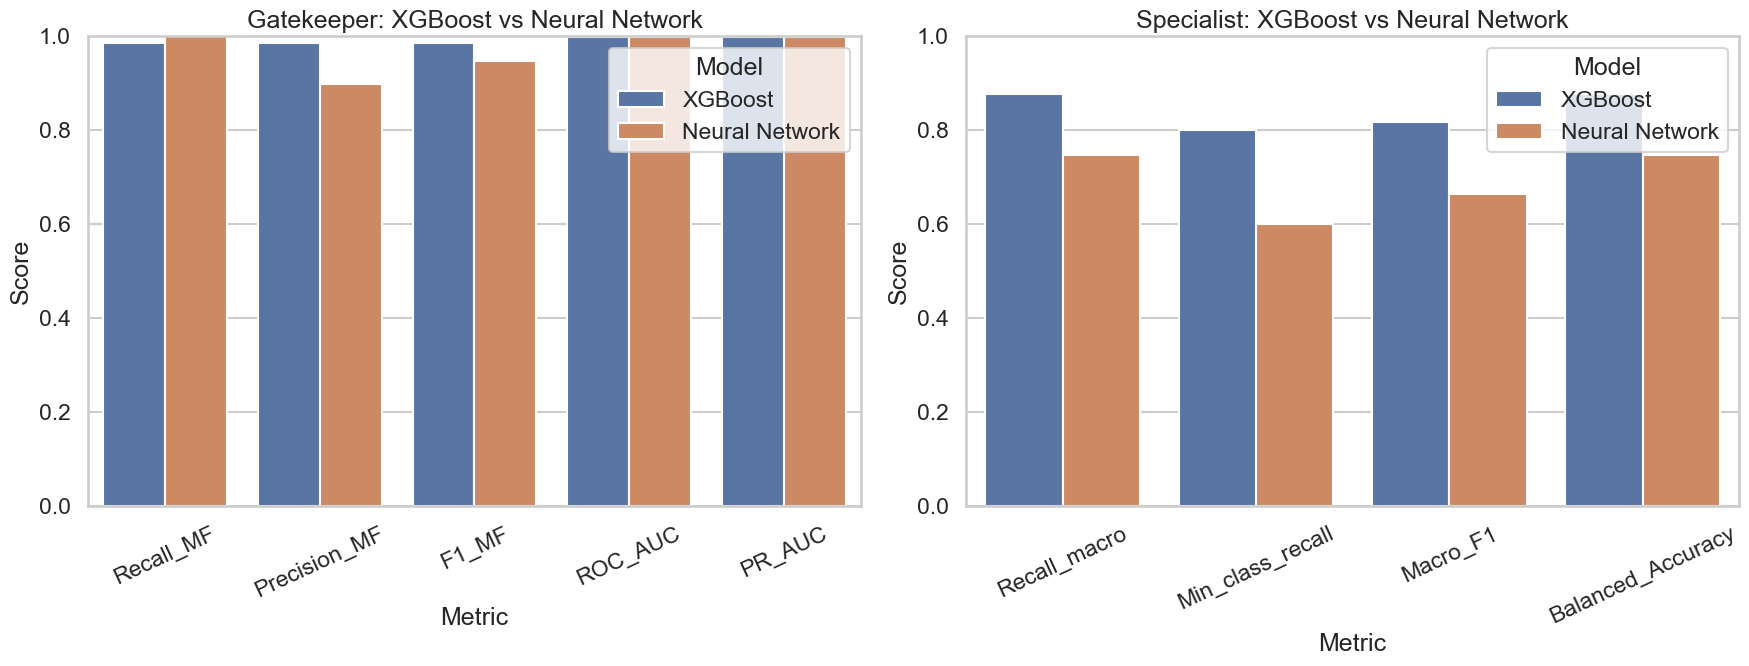

In [17]:
# ===============================================
# FINAL COMPARISON: XGBoost vs Neural Network
# ===============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, precision_score, f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score

sns.set_theme(style="whitegrid", context="talk")

def to_1d_labels(arr):
    arr = np.asarray(arr)
    if arr.ndim > 1:
        arr = np.argmax(arr, axis=1)
    return arr.astype(int).ravel()

# Safety checks
required_objects = [
    'fitted_pipelines', 'specialist_results', 'nn_artifacts',
    'X_test', 'y_test', 'X_test_s', 'y_test_s'
]
for obj in required_objects:
    if obj not in globals():
        raise ValueError(f"Missing required object: {obj}. Re-run training cells before this comparison.")

# -------------------------------
# Gatekeeper: XGBoost vs NN
# -------------------------------
xgb_gate = fitted_pipelines['XGBoost']
y_true_g = to_1d_labels(y_test)
y_pred_xgb_g = to_1d_labels(xgb_gate.predict(X_test))
y_prob_xgb_g = xgb_gate.predict_proba(X_test)[:, 1]

nn_gate = nn_artifacts['gatekeeper_model']
pre_gate = nn_artifacts['gatekeeper_preprocessor']
th_g = nn_artifacts['gatekeeper_threshold']
Xg_test_enc = pre_gate.transform(X_test)
y_prob_nn_g = nn_gate.predict_proba(Xg_test_enc)[:, 1]
y_pred_nn_g = (y_prob_nn_g >= th_g).astype(int)

gate_cmp = pd.DataFrame(
    [
        {
            'Model': 'XGBoost',
            'Task': 'Gatekeeper',
            'Recall_MF': recall_score(y_true_g, y_pred_xgb_g, zero_division=0),
            'Precision_MF': precision_score(y_true_g, y_pred_xgb_g, zero_division=0),
            'F1_MF': f1_score(y_true_g, y_pred_xgb_g, zero_division=0),
            'ROC_AUC': roc_auc_score(y_true_g, y_prob_xgb_g),
            'PR_AUC': average_precision_score(y_true_g, y_prob_xgb_g),
        },
        {
            'Model': 'Neural Network',
            'Task': 'Gatekeeper',
            'Recall_MF': recall_score(y_true_g, y_pred_nn_g, zero_division=0),
            'Precision_MF': precision_score(y_true_g, y_pred_nn_g, zero_division=0),
            'F1_MF': f1_score(y_true_g, y_pred_nn_g, zero_division=0),
            'ROC_AUC': roc_auc_score(y_true_g, y_prob_nn_g),
            'PR_AUC': average_precision_score(y_true_g, y_prob_nn_g),
        },
    ]
)

# -------------------------------
# Specialist: XGBoost vs NN
# -------------------------------
xgb_spec = specialist_results['XGBoost (Multiclass)']['pipeline']
y_true_s_cmp = to_1d_labels(y_test_s)
y_pred_xgb_s = to_1d_labels(xgb_spec.predict(X_test_s))

nn_spec = nn_artifacts['specialist_model']
pre_spec = nn_artifacts['specialist_preprocessor']
Xs_test_enc = pre_spec.transform(X_test_s)
y_pred_nn_s = to_1d_labels(nn_spec.predict(Xs_test_enc))

classes = np.unique(y_true_s_cmp)

spec_cmp = pd.DataFrame(
    [
        {
            'Model': 'XGBoost',
            'Task': 'Specialist',
            'Recall_macro': recall_score(y_true_s_cmp, y_pred_xgb_s, average='macro', zero_division=0),
            'Min_class_recall': recall_score(y_true_s_cmp, y_pred_xgb_s, labels=classes, average=None, zero_division=0).min(),
            'Macro_F1': f1_score(y_true_s_cmp, y_pred_xgb_s, average='macro', zero_division=0),
            'Balanced_Accuracy': balanced_accuracy_score(y_true_s_cmp, y_pred_xgb_s),
        },
        {
            'Model': 'Neural Network',
            'Task': 'Specialist',
            'Recall_macro': recall_score(y_true_s_cmp, y_pred_nn_s, average='macro', zero_division=0),
            'Min_class_recall': recall_score(y_true_s_cmp, y_pred_nn_s, labels=classes, average=None, zero_division=0).min(),
            'Macro_F1': f1_score(y_true_s_cmp, y_pred_nn_s, average='macro', zero_division=0),
            'Balanced_Accuracy': balanced_accuracy_score(y_true_s_cmp, y_pred_nn_s),
        },
    ]
)

print('--- Gatekeeper Comparison ---')
print(gate_cmp)
print('\n--- Specialist Comparison ---')
print(spec_cmp)

# -------------------------------
# Visualization
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

gate_plot = gate_cmp.melt(
    id_vars=['Model', 'Task'],
    value_vars=['Recall_MF', 'Precision_MF', 'F1_MF', 'ROC_AUC', 'PR_AUC'],
    var_name='Metric',
    value_name='Score',
)
sns.barplot(data=gate_plot, x='Metric', y='Score', hue='Model', ax=axes[0])
axes[0].set_title('Gatekeeper: XGBoost vs Neural Network')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=25)

spec_plot = spec_cmp.melt(
    id_vars=['Model', 'Task'],
    value_vars=['Recall_macro', 'Min_class_recall', 'Macro_F1', 'Balanced_Accuracy'],
    var_name='Metric',
    value_name='Score',
)
sns.barplot(data=spec_plot, x='Metric', y='Score', hue='Model', ax=axes[1])
axes[1].set_title('Specialist: XGBoost vs Neural Network')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()